# Unsupervised HP search + multi-seed finals

Hyperparameters are selected by **held-out unsupervised metrics** (Bernoulli LL for LV / LV+$e$ / GNN / GNN$_e$; negated mean Jaccard cost for NTAC; negated row MSE for PCA). Ground-truth Hungarian / ARI / NMI are reported only on multi-seed final runs.

Expected artifacts from `run_experiments.py` / `launch_lightning_sweep.py`:
- `hp_results.csv`, `hp_best.json`
- `final_results.csv`, `final_summary.csv`

This notebook adapts to whichever methods are present (e.g. `pca`, `lv`, `lv_e`, `gnn`, `gnn_e`, `ntac`). Reference lines on the finals plot: random $K$-assignment baseline and theoretical Hungarian max ($n_{\mathrm{shared}}$).

In [11]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 120
PALETTE = {
    "pca": "#6c757d",
    "lv": "#e76f51",
    "lv_e": "#2a9d8f",
    "gnn": "#2a6f97",
    "gnn_e": "#264653",
    "ntac": "#bc6c25",
}
METHOD_ORDER = ["pca", "lv", "lv_e", "gnn", "gnn_e", "ntac"]


def methods_present(df: pd.DataFrame) -> list[str]:
    found = set(df["method"].unique())
    return [m for m in METHOD_ORDER if m in found] + sorted(found - set(METHOD_ORDER))

## 1. Hyperparameter search (unsupervised selection)

In [12]:
hp = pd.read_csv("hp_results.csv")
best = json.loads(Path("hp_best.json").read_text())
display(hp.sort_values(["method", "val_metric"], ascending=[True, False]).groupby("method").head(5))
print("Selected by val_metric:")
display(pd.DataFrame([
    {"method": m, "name": v["name"], "val_metric": v["val_metric"], **v["hyperparams"]}
    for m, v in best.items()
]))

,d,d_e,e_wd,gt_ari,gt_hungarian,gt_n_gt_clusters,gt_n_pred_clusters,gt_n_shared,gt_nmi,lr,method,n_pred_clusters,name,phase,val_metric,val_metric_name
5,64,NaN,NaN,0.006870,1440.0,729.0,728.0,46479.0,0.206314,0.10,lv,729,hp_lv_d64_lr0.1,hp,-3.695974,heldout_bernoulli_ll
3,32,NaN,NaN,0.006017,1404.0,729.0,726.0,46479.0,0.204350,0.10,lv,729,hp_lv_d32_lr0.1,hp,-3.739585,heldout_bernoulli_ll
2,32,NaN,NaN,0.002691,1223.0,729.0,671.0,46479.0,0.197028,0.05,lv,700,hp_lv_d32_lr0.05,hp,-3.820687,heldout_bernoulli_ll
4,64,NaN,NaN,0.003101,1252.0,729.0,711.0,46479.0,0.199028,0.05,lv,726,hp_lv_d64_lr0.05,hp,-3.860585,heldout_bernoulli_ll
15,64,16.0,0.010,0.029090,2373.0,729.0,697.0,46479.0,0.201104,0.05,lv_e,718,hp_lv_e_d64_de16_lr0.05_ewd0.01,hp,-3.635422,heldout_bernoulli_ll
6,32,16.0,0.001,0.029603,2432.0,729.0,591.0,46479.0,0.193620,0.05,lv_e,627,hp_lv_e_d32_de16_lr0.05_ewd0.001,hp,-3.643739,heldout_bernoulli_ll
9,32,16.0,0.010,0.031520,2583.0,729.0,686.0,46479.0,0.199422,0.10,lv_e,711,hp_lv_e_d32_de16_lr0.1_ewd0.01,hp,-3.667319,heldout_bernoulli_ll
8,32,16.0,0.001,0.039515,2953.0,729.0,690.0,46479.0,0.205984,0.10,lv_e,713,hp_lv_e_d32_de16_lr0.1_ewd0.001,hp,-3.671640,heldout_bernoulli_ll
14,64,16.0,0.001,0.035983,2639.0,729.0,700.0,46479.0,0.205663,0.05,lv_e,719,hp_lv_e_d64_de16_lr0.05_ewd0.001,hp,-3.675817,heldout_bernoulli_ll
0,32,NaN,NaN,0.018084,1692.0,729.0,697.0,46479.0,0.223074,0.01,pca,729,hp_pca_d32_lr0.01,hp,-53.905715,neg_heldout_row_mse


Selected by val_metric:


,method,name,val_metric,d,lr,d_e,e_wd
0,pca,hp_pca_d32_lr0.01,-53.905715,32,0.01,NaN,NaN
1,lv,hp_lv_d64_lr0.1,-3.695974,64,0.10,NaN,NaN
2,lv_e,hp_lv_e_d64_de16_lr0.05_ewd0.01,-3.635422,64,0.05,16.0,0.01


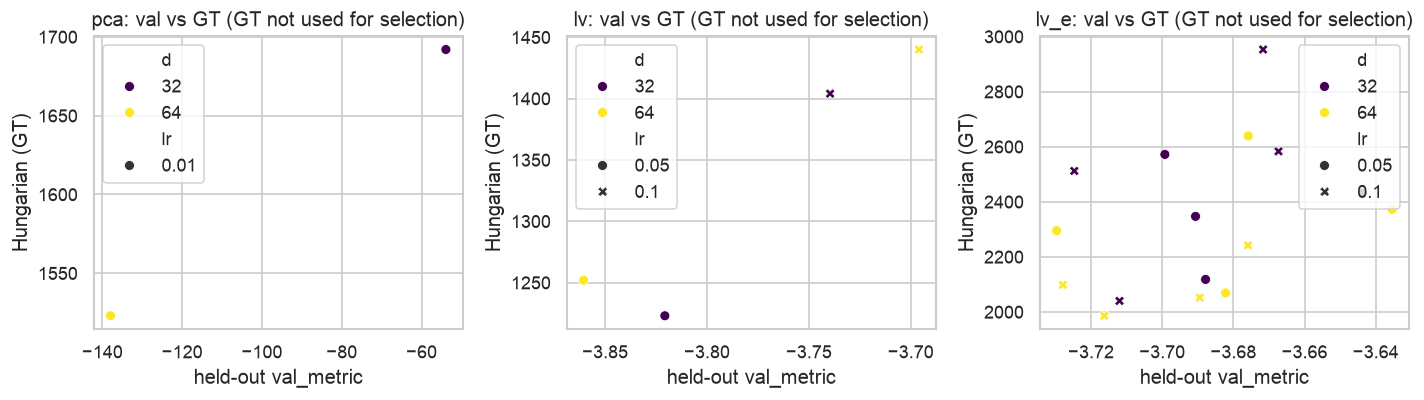

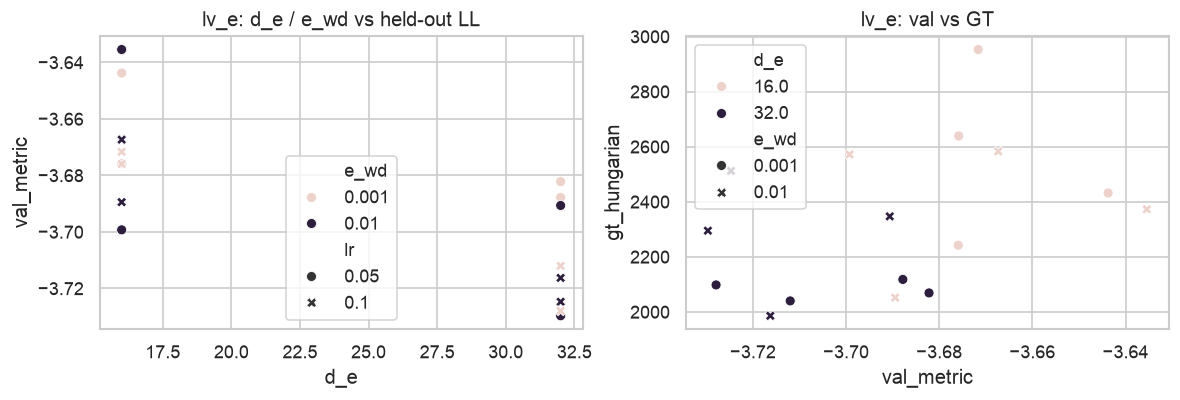

In [13]:
methods = methods_present(hp)
n = max(len(methods), 1)
fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 3.5), sharey=False)
if n == 1:
    axes = [axes]
for ax, method in zip(axes, methods):
    sub = hp[hp["method"] == method].copy()
    sns.scatterplot(
        data=sub, x="val_metric", y="gt_hungarian",
        hue="d", style="lr", ax=ax, palette="viridis",
    )
    ax.set_title(f"{method}: val vs GT (GT not used for selection)")
    ax.set_xlabel("held-out val_metric")
    ax.set_ylabel("Hungarian (GT)")
plt.tight_layout()
plt.show()

# LV+e: residual dim / weight decay vs held-out LL (if present)
if "lv_e" in methods and {"d_e", "e_wd"}.issubset(hp.columns):
    sub = hp[hp["method"] == "lv_e"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    sns.scatterplot(data=sub, x="d_e", y="val_metric", hue="e_wd", style="lr", ax=axes[0])
    axes[0].set_title("lv_e: d_e / e_wd vs held-out LL")
    axes[0].set_ylabel("val_metric")
    sns.scatterplot(data=sub, x="val_metric", y="gt_hungarian", hue="d_e", style="e_wd", ax=axes[1])
    axes[1].set_title("lv_e: val vs GT")
    plt.tight_layout()
    plt.show()

## 2. Multi-seed uncertainty (final runs)

In [14]:
from evaluate_clustering import (
    align_assignments,
    encode_labels,
    load_assignment_dict,
    load_ground_truth,
    random_assignment_baseline,
)

final = pd.read_csv("final_results.csv")
summary = pd.read_csv("final_summary.csv")
display(summary)
display(final.sort_values(["method", "seed"]))

# Random baseline + theoretical max on the same shared GT set as the finals.
gt = load_ground_truth(Path("root_id_type_dict.pkl"))
pred_paths = sorted(Path(".").glob("final_*_assignment_dict*.npy"))
if pred_paths:
    pred0 = load_assignment_dict(pred_paths[0])
    gt_labels, _, shared = align_assignments(pred0, gt)
else:
    gt_labels, _ = encode_labels(list(gt.values()))
    shared = list(gt.keys())

k_pred = 729
rand_base = random_assignment_baseline(gt_labels, k=k_pred, n_seeds=20, seed=0)
print(
    f"Random (K={k_pred}, n={len(shared)}, 20 seeds): "
    f"Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"| ARI {rand_base['ari_mean']:.4f} ± {rand_base['ari_std']:.4f} "
    f"| NMI {rand_base['nmi_mean']:.4f} ± {rand_base['nmi_std']:.4f}"
)
print(
    f"Theoretical max (perfect recovery): Hungarian {rand_base['hungarian_max']:.0f}, "
    f"ARI {rand_base['ari_max']:.0f}, NMI {rand_base['nmi_max']:.0f}"
)

,ari_mean,ari_std,hp_d,hp_d_e,hp_e_wd,hp_lr,hungarian_mean,hungarian_std,method,n_seeds,nmi_mean,nmi_std,selection_val_metric
0,0.046468,0.013314,64,NaN,NaN,0.10,2546.000000,392.034437,lv,3,0.223883,0.001714,-3.695974
1,0.065963,0.014970,64,16.0,0.01,0.05,3496.666667,363.469852,lv_e,3,0.254628,0.001954,-3.635422
2,0.008135,0.002646,32,NaN,NaN,0.01,1355.000000,88.831301,pca,3,0.224727,0.008043,-53.905715


,d,d_e,e_wd,gt_ari,gt_hungarian,gt_n_gt_clusters,gt_n_pred_clusters,gt_n_shared,gt_nmi,lr,method,name,phase,seed,val_metric
3,64,NaN,NaN,0.059646,2941.0,729.0,725.0,46479.0,0.225610,0.10,lv,final_lv_d64_lr0.1_seed0,final,0,-3.868075
4,64,NaN,NaN,0.046737,2540.0,729.0,728.0,46479.0,0.223858,0.10,lv,final_lv_d64_lr0.1_seed1,final,1,-3.816701
5,64,NaN,NaN,0.033022,2157.0,729.0,728.0,46479.0,0.222182,0.10,lv,final_lv_d64_lr0.1_seed2,final,2,-3.830568
6,64,16.0,0.01,0.064913,3599.0,729.0,670.0,46479.0,0.253575,0.05,lv_e,final_lv_e_d64_de16_lr0.05_ewd0.01_seed0,final,0,-3.207561
7,64,16.0,0.01,0.051545,3093.0,729.0,660.0,46479.0,0.253427,0.05,lv_e,final_lv_e_d64_de16_lr0.05_ewd0.01_seed1,final,1,-3.205974
8,64,16.0,0.01,0.081430,3798.0,729.0,645.0,46479.0,0.256883,0.05,lv_e,final_lv_e_d64_de16_lr0.05_ewd0.01_seed2,final,2,-3.205772
0,32,NaN,NaN,0.009491,1369.0,729.0,619.0,46479.0,0.219383,0.01,pca,final_pca_d32_lr0.01_seed0,final,0,-1.480807
1,32,NaN,NaN,0.009829,1436.0,729.0,647.0,46479.0,0.220821,0.01,pca,final_pca_d32_lr0.01_seed1,final,1,-5.363856
2,32,NaN,NaN,0.005086,1260.0,729.0,632.0,46479.0,0.233977,0.01,pca,final_pca_d32_lr0.01_seed2,final,2,-4.243975


Random (K=729, n=46479, 20 seeds): Hungarian 980.0 ± 8.0 | ARI 0.0000 ± 0.0000 | NMI 0.2015 ± 0.0003
Theoretical max (perfect recovery): Hungarian 46479, ARI 1, NMI 1


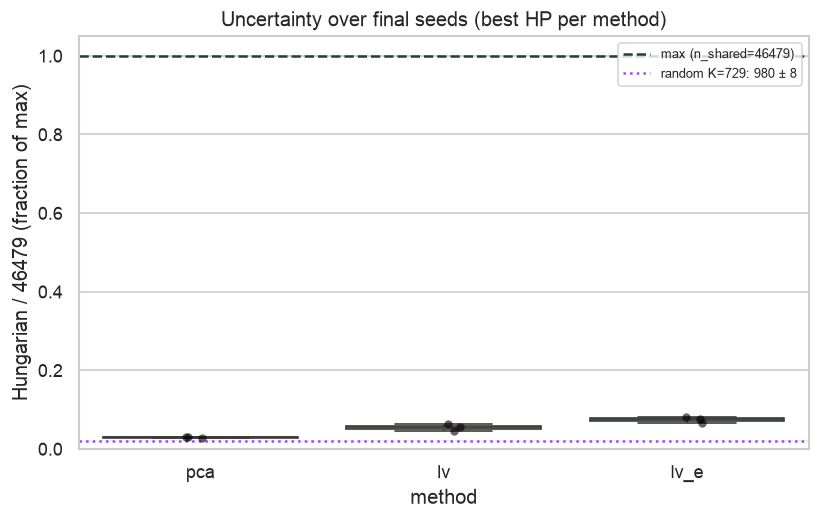

lv_e: Hungarian 3496.7 ± 363.5 (7.52% of max); ARI 0.066 ± 0.015, NMI 0.255 ± 0.002
lv: Hungarian 2546.0 ± 392.0 (5.48% of max); ARI 0.046 ± 0.013, NMI 0.224 ± 0.002
pca: Hungarian 1355.0 ± 88.8 (2.92% of max); ARI 0.008 ± 0.003, NMI 0.225 ± 0.008
random: Hungarian 980.0 ± 8.0 (2.11% of max); ARI 0.000 ± 0.000, NMI 0.202 ± 0.000
max:    Hungarian 46479 (100%; ARI/NMI = 1)


In [15]:
# Plot as fraction of theoretical max so random + ceiling are on-scale.
n_shared = float(rand_base["hungarian_max"])
plot_df = final.copy()
plot_df["hungarian_frac"] = plot_df["gt_hungarian"] / n_shared
rand_frac = rand_base["hungarian_mean"] / n_shared
rand_frac_std = rand_base["hungarian_std"] / n_shared

fig, ax = plt.subplots(figsize=(7, 4.5))
order = methods_present(final)
palette = {m: PALETTE.get(m, "#333333") for m in order}
sns.boxplot(
    data=plot_df, x="method", y="hungarian_frac", order=order,
    hue="method", palette=palette, legend=False, ax=ax,
)
sns.stripplot(
    data=plot_df, x="method", y="hungarian_frac", order=order,
    color="black", alpha=0.6, ax=ax,
)
ax.axhline(1.0, color="#1b4332", ls="--", lw=1.5, label=f"max (n_shared={n_shared:.0f})")
ax.axhline(
    rand_frac,
    color="#9d4edd",
    ls=":",
    lw=1.5,
    label=f"random K={k_pred}: {rand_base['hungarian_mean']:.0f} ± {rand_base['hungarian_std']:.0f}",
)
ax.axhspan(
    rand_frac - rand_frac_std,
    rand_frac + rand_frac_std,
    color="#9d4edd",
    alpha=0.12,
    zorder=0,
)
ax.set_ylim(0, 1.05)
ax.set_ylabel(f"Hungarian / {n_shared:.0f} (fraction of max)")
ax.set_title("Uncertainty over final seeds (best HP per method)")
ax.legend(loc="upper right", fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

for _, row in summary.sort_values("hungarian_mean", ascending=False).iterrows():
    print(
        f"{row['method']}: Hungarian {row['hungarian_mean']:.1f} ± {row['hungarian_std']:.1f} "
        f"({100 * row['hungarian_mean'] / n_shared:.2f}% of max); "
        f"ARI {row['ari_mean']:.3f} ± {row['ari_std']:.3f}, "
        f"NMI {row['nmi_mean']:.3f} ± {row['nmi_std']:.3f}"
    )
print(
    f"random: Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"({100 * rand_frac:.2f}% of max); "
    f"ARI {rand_base['ari_mean']:.3f} ± {rand_base['ari_std']:.3f}, "
    f"NMI {rand_base['nmi_mean']:.3f} ± {rand_base['nmi_std']:.3f}"
)
print(f"max:    Hungarian {n_shared:.0f} (100%; ARI/NMI = 1)")